# Backhoe Loader and Excavator Detection in Construction Images

## Use case

Construction teams may hire several types of heavy equipment during a project. Reviewing site images for backhoe loaders and excavators could provide an initial record of which types are visible, helping a person compare observations with separate equipment-hire or time logs.

This prototype detects and labels visible **Backhoe Loaders** and **excavators** in individual images. It does not identify a particular machine, measure operating hours, calculate hire costs, or establish the total number of unique machines on site. Those tasks would need additional records and a way to avoid counting the same machine across multiple photographs.

## Project question

Can a small object-detection model distinguish backhoe loaders from excavators in construction images and avoid detecting either class in images with no target equipment?

## What this notebook contains

The notebook records the dataset source and quality checks, training configuration, evaluation metrics, example predictions, observed errors, and practical limitations. Its code cells show how the reported model and results were produced.

## 1. Environment check

This cell installs Ultralytics and records its version and the available GPU. Recording the environment helps another person reproduce the training run and understand the resources used.

In [16]:
%pip install -q ultralytics==8.4.163 pyyaml

import torch
import ultralytics

print("Ultralytics:", ultralytics.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Ultralytics: 8.4.163
GPU available: True
GPU: Tesla T4


## 2. Load and verify the dataset

Roboflow version 3 contains 131 exported images: 105 for training, 13 for validation, and 13 for testing. Related views were placed in the same split where identified. Five source images tagged for exclusion were omitted when the version was generated.

This cell downloads the frozen YOLOv11-format export from the project's public GitHub Release. Its SHA256 fingerprint checks that the downloaded bytes match the export used for this study; no Roboflow login or API key is required. The cell then fixes the dataset paths in `data.yaml` for this Colab session. The Release must be published before running this cell.


In [ ]:
from pathlib import Path
from zipfile import ZipFile
import hashlib
import urllib.request
import yaml

# This URL will work after the named ZIP is attached to the public v1.0.0 Release.
DATA_URL = "https://github.com/Asiya0555/Backhoe-Excavator-Site-Detection/releases/download/v1.0.0/backhoe-excavator-v3-yolov11.zip"
EXPECTED_SHA256 = "8e3645e885a7f4b3ec90c25cdf39b680a474448659397f123ac13a7d28ccab8a"
ZIP_PATH = Path("/content/backhoe-excavator-v3-yolov11.zip")
ROOT = Path("/content/dataset")

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

# An existing good ZIP can be reused if this cell is rerun in the same session.
if ZIP_PATH.exists() and sha256_file(ZIP_PATH) != EXPECTED_SHA256:
    ZIP_PATH.unlink()
if not ZIP_PATH.exists():
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

actual_sha256 = sha256_file(ZIP_PATH)
print("ZIP SHA256:", actual_sha256)
if actual_sha256 != EXPECTED_SHA256:
    ZIP_PATH.unlink(missing_ok=True)
    raise AssertionError("Downloaded ZIP differs from the version 3 export.")

ROOT.mkdir(parents=True, exist_ok=True)
with ZipFile(ZIP_PATH) as archive:
    assert archive.testzip() is None, "The ZIP is damaged."
    archive.extractall(ROOT)

yaml_files = list(ROOT.rglob("data.yaml"))
assert len(yaml_files) == 1, f"Expected one data.yaml, found {yaml_files}"
cfg_path = yaml_files[0]
dataset_root = cfg_path.parent
cfg = yaml.safe_load(cfg_path.read_text())
cfg["path"] = str(dataset_root)
cfg["train"] = "train/images"
cfg["val"] = "valid/images"
cfg["test"] = "test/images"
cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False))

assert cfg["names"] == ["Backhoe Loader", "excavator"], cfg["names"]
for split, expected in (("train", 105), ("valid", 13), ("test", 13)):
    count = len(list((dataset_root / split / "images").glob("*.jpg")))
    assert count == expected, f"{split}: expected {expected} images, found {count}"
    print(f"{split}: {count} images")

print("Training configuration:", cfg_path)
print("Classes:", cfg["names"])


## 3. Check class balance and negative images

This check counts images and object annotations in each split. Annotation counts can exceed image counts because one image can contain multiple objects. An empty label file represents an image with neither target; it does not create a third class. Both target classes should appear in training, validation, and testing.

In [3]:
from collections import Counter
import pandas as pd

summary = []

for split in ("train", "valid", "test"):
    image_dir = dataset_root / split / "images"
    label_dir = dataset_root / split / "labels"
    images = sorted(image_dir.glob("*.jpg"))

    class_counts = Counter()
    negative_images = 0
    polygon_annotations = 0

    for image_path in images:
        label_path = label_dir / f"{image_path.stem}.txt"
        if not label_path.exists():
            raise FileNotFoundError(f"Missing label: {label_path}")

        lines = [line.strip() for line in label_path.read_text().splitlines()
                 if line.strip()]

        if not lines:
            negative_images += 1

        for line in lines:
            values = line.split()
            class_counts[int(values[0])] += 1
            if len(values) > 5:
                polygon_annotations += 1

    summary.append({
        "Split": split,
        "Images": len(images),
        "Backhoe Loader annotations": class_counts[0],
        "Excavator annotations": class_counts[1],
        "Negative images": negative_images,
        "Polygon annotations": polygon_annotations,
    })

split_summary = pd.DataFrame(summary)
display(split_summary)

,Split,Images,Backhoe Loader annotations,Excavator annotations,Negative images,Polygon annotations
0,train,105,71,48,8,13
1,valid,13,7,4,2,0
2,test,13,7,5,1,0


### 3.1. Examples of saved training annotations

These four training photos show the saved ground-truth annotations: two backhoe-loader examples and two excavator scenes. The boxes are reconstructed from the exported YOLO label files, not predicted by the model. Each box label records a class ID followed by normalized centre x, centre y, width, and height. Displaying the images and their boxes helps check what the model was asked to learn.

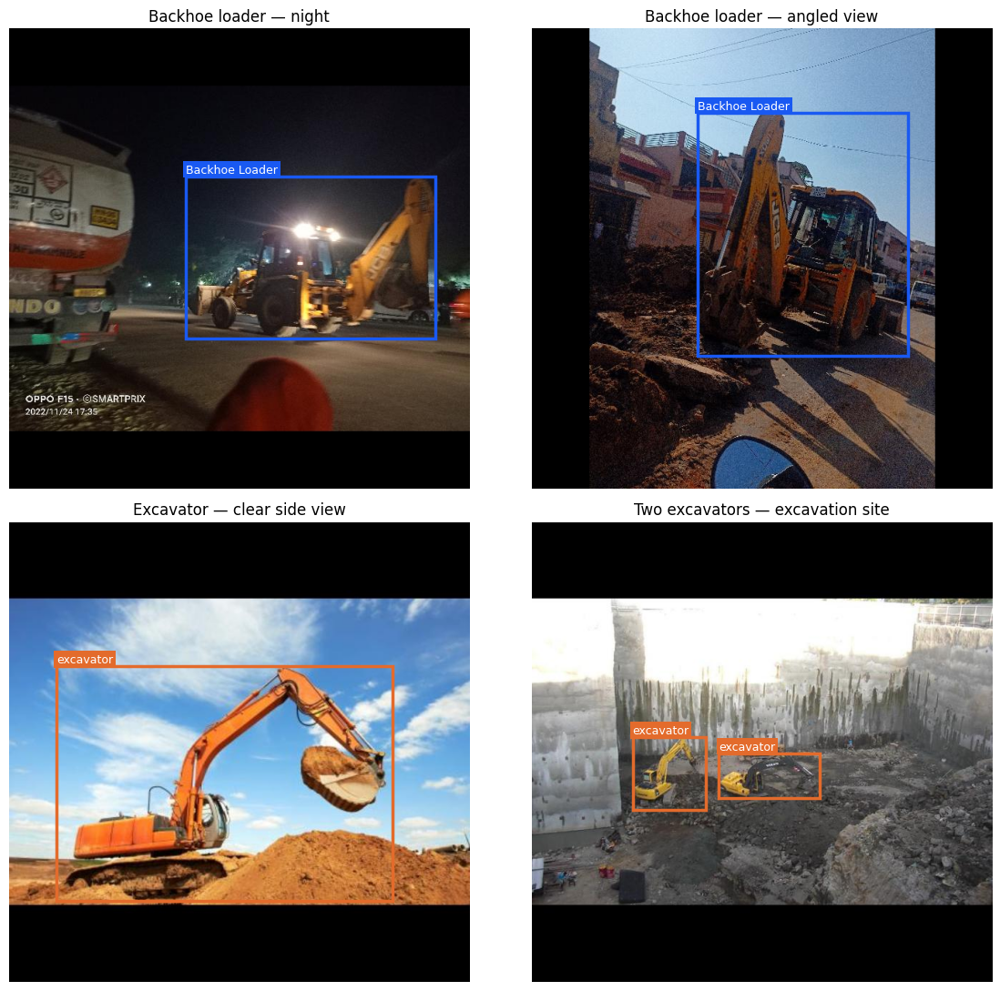

Saved annotation examples: /content/runs/annotation_examples.png


In [15]:
from pathlib import Path
from PIL import Image as PILImage
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import yaml

examples = [
    ("Backhoe loader — night", "8cdca2ea8c2a9f6c8e882df44c057f6a"),
    ("Backhoe loader — angled view", "7416bb555a4bed3227541c4709e7c016"),
    ("Excavator — clear side view", "6c9bf902f96827b3a3e4b1eab59626e8"),
    ("Two excavators — excavation site", "e5a19ef8ab6788899e047dcb8159b3ff"),
]

dataset_dir = Path(cfg_path).parent
class_names = yaml.safe_load(Path(cfg_path).read_text())["names"]
colors = {0: "#1959F2", 1: "#E36B2C"}

fig, axes = plt.subplots(2, 2, figsize=(12, 11))

for ax, (title, image_id) in zip(axes.flat, examples):
    matches = list((dataset_dir / "train" / "images").glob(f"*.rf.{image_id}.jpg"))
    assert len(matches) == 1, f"Expected one training image for {title}."

    image_path = matches[0]
    label_path = dataset_dir / "train" / "labels" / f"{image_path.stem}.txt"
    photo = PILImage.open(image_path).convert("RGB")
    image_width, image_height = photo.size

    ax.imshow(photo)
    ax.set_title(title)
    ax.axis("off")

    for line in label_path.read_text().splitlines():
        if not line.strip():
            continue

        values = line.split()
        assert len(values) == 5, f"Unexpected label format: {label_path}"
        class_id = int(values[0])
        centre_x, centre_y, box_width, box_height = map(float, values[1:])

        left = (centre_x - box_width / 2) * image_width
        top = (centre_y - box_height / 2) * image_height
        width = box_width * image_width
        height = box_height * image_height
        color = colors[class_id]

        ax.add_patch(Rectangle(
            (left, top), width, height,
            fill=False, edgecolor=color, linewidth=2.5
        ))
        ax.text(
            left, max(0, top - 5), class_names[class_id],
            color="white", fontsize=9,
            bbox={"facecolor": color, "edgecolor": "none", "pad": 2}
        )

plt.tight_layout()
annotation_grid = Path("/content/runs/annotation_examples.png")
annotation_grid.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(annotation_grid, dpi=140, bbox_inches="tight")
plt.show()
print("Saved annotation examples:", annotation_grid)

## 4. Train the initial detector

A pretrained YOLO26 nano model is adapted to the two equipment classes. Training uses the training images; the validation images help assess performance during training. The test images are reserved for final evaluation.

The initial run uses 30 epochs, a batch size of 16, and 640 × 640 input images. A fixed random seed is recorded, and training plots and weights are saved. The Roboflow **YOLOv11 export** describes the dataset format; **YOLO26n** is the model being trained.

In [4]:
from ultralytics import YOLO
import torch
import time

model = YOLO("yolo26n.pt")  # Start with pretrained detection weights.
device = 0 if torch.cuda.is_available() else "cpu"

start_time = time.time()

training_results = model.train(
    data=str(cfg_path),
    epochs=30,
    batch=16,
    imgsz=640,
    device=device,
    seed=42,
    project="/content/runs",
    name="backhoe_excavator_v3_yolo26n",
    plots=True,
)

print(f"Training time: {(time.time() - start_time) / 60:.1f} minutes")
print("Results folder:", model.trainer.save_dir)
print("Best weights:", model.trainer.best)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=backhoe_excavator_v3_yolo26n, nbs=64, nms=None, o

## 5. Review the training results

The model was trained for 30 epochs. Training box loss decreased from 1.219 to 0.9711, indicating improved box placement on the training batches. The validation metrics and plots provide a separate check of how the saved model performs on images outside the training split. Because the validation set contains only 11 labelled objects, these estimates should be interpreted cautiously.

results.png


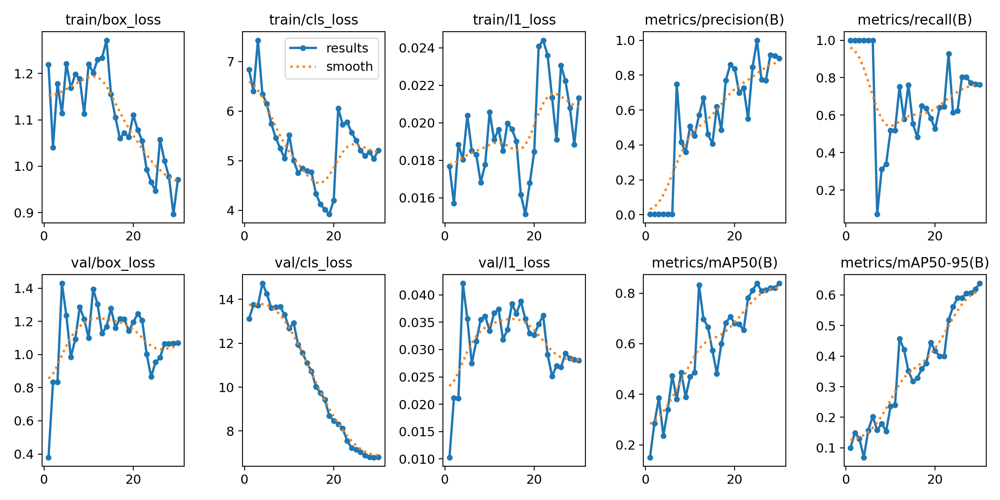

confusion_matrix.png


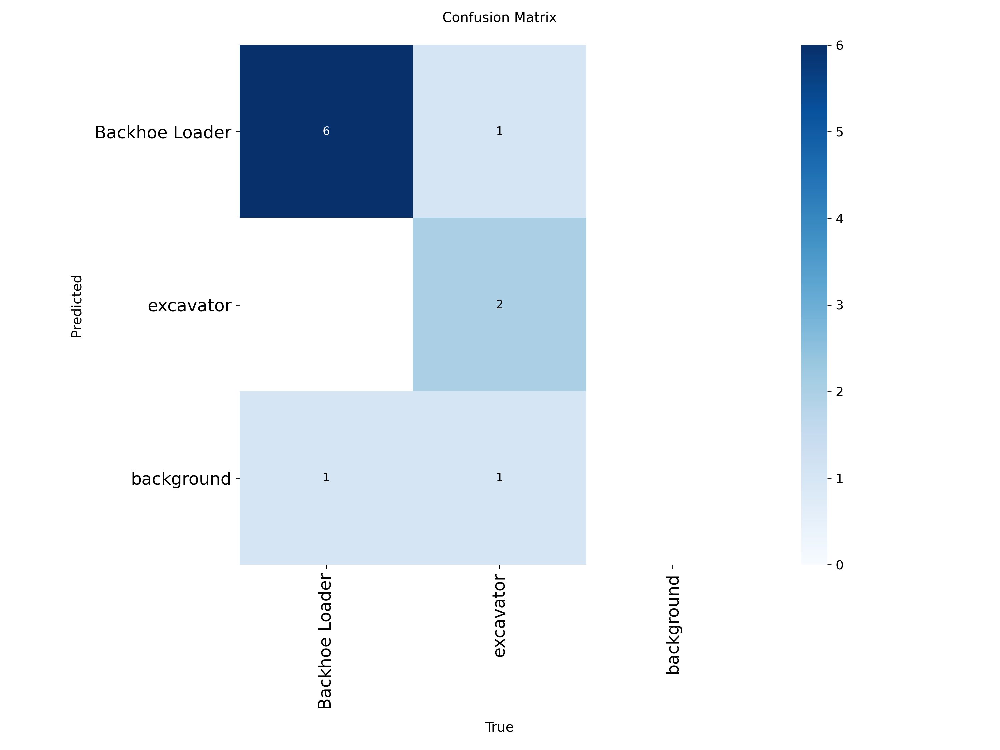

In [17]:
from pathlib import Path
from IPython.display import Image, display

train_run = Path(model.trainer.save_dir)

for filename in ("results.png", "confusion_matrix.png"):
    plot_path = train_run / filename
    if plot_path.exists():
        print(filename)
        display(Image(filename=str(plot_path), width=800))

YOLO’s results.png shows training box loss and validation class loss decreasing overall, while validation mAP increases over 30 epochs. Training class loss rises again after about epoch 20, and L1 loss fluctuates, so improvement is not uniform across every loss component. So the result is promising but should be interpreted alongside the small validation set and the held-out test results.

### Why does the confusion matrix show “background”?

The model was trained with two classes: Backhoe Loader and excavator. “Background” is an extra evaluation row and column added by Ultralytics; it is not a third dataset label. A labelled machine matched to background represents a missed detection (false negative). A predicted machine matched to background represents a detection without a matching labelled target (false positive). This lets the chart account for missed and extra boxes. An image with no target and no prediction does not necessarily add a visible background-to-background count.

## 6. Evaluate on the test split

The best checkpoint was selected using validation results. It is now evaluated on the 13 test images, which were kept out of training and checkpoint selection. Precision, recall, mAP50, and mAP50–95 provide a final quantitative check; individual predictions will also be reviewed because this test set is small.

In [10]:
from ultralytics import YOLO

best_path = Path(model.trainer.best)
assert best_path.is_file(), f"Missing model weights: {best_path}"

best_model = YOLO(str(best_path))

test_metrics = best_model.val(
    data=str(cfg_path),
    split="test",
    imgsz=640,
    batch=16,
    device=device,
    plots=True,
    project="/content/runs",
    name="test_v3_yolo26n",
    exist_ok=True,
)

print("TEST RESULTS")
print(f"Precision:  {test_metrics.box.mp:.3f}")
print(f"Recall:     {test_metrics.box.mr:.3f}")
print(f"mAP50:      {test_metrics.box.map50:.3f}")
print(f"mAP50–95:   {test_metrics.box.map:.3f}")
print("Plots:", test_metrics.save_dir)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1788.1±349.9 MB/s, size: 78.9 KB)
val: Scanning /content/dataset/test/labels.cache... 13 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13/13 3.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.3it/s 0.2s
                   all         13         12      0.812      0.904      0.938      0.677
        Backhoe Loader          7          7      0.922      0.857      0.978      0.708
             excavator          5          5      0.702       0.95      0.898      0.646
Speed: 0.4ms preprocess, 5.2ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/test_v3_yolo26n
TEST RESULTS
Precision:  0.812
Recall:     0.904
mAP50:      0.938
mAP50–95:   0.677
Plots: /content/

In [9]:
from pathlib import Path
from IPython.display import Markdown, display
import pandas as pd

# Follow the run that actually completed, even if Colab adds "2" to its folder name.
train_run = Path(model.trainer.save_dir)
best_path = Path(model.trainer.best)

history = pd.read_csv(train_run / "results.csv")
history.columns = history.columns.str.strip()
first_box_loss = history["train/box_loss"].iloc[0]
last_box_loss = history["train/box_loss"].iloc[-1]

def split_counts(split):
    root = Path(cfg_path).parent / split
    images = sorted(
        p for p in (root / "images").iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
    )
    object_counts = []
    for image_path in images:
        label_path = root / "labels" / f"{image_path.stem}.txt"
        lines = label_path.read_text().splitlines() if label_path.exists() else []
        object_counts.append(sum(bool(line.strip()) for line in lines))
    return len(images), sum(object_counts), sum(n == 0 for n in object_counts)

v_images, v_objects, v_negative = split_counts("valid")
t_images, t_objects, t_negative = split_counts("test")

display(Markdown(f"""
### Results from this notebook run

Training completed **{len(history)} epochs**. Training box loss changed from
**{first_box_loss:.3f}** to **{last_box_loss:.3f}**.

| Split | Images | Labelled objects | Images without a target | Precision | Recall | mAP50 | mAP50–95 |
|---|---:|---:|---:|---:|---:|---:|---:|
| Validation | {v_images} | {v_objects} | {v_negative} | {training_results.box.mp:.3f} | {training_results.box.mr:.3f} | {training_results.box.map50:.3f} | {training_results.box.map:.3f} |
| Test | {t_images} | {t_objects} | {t_negative} | {test_metrics.box.mp:.3f} | {test_metrics.box.mr:.3f} | {test_metrics.box.map50:.3f} | {test_metrics.box.map:.3f} |

These are results from the current execution. The small evaluation splits make
the estimates sensitive to individual images.
"""))


### Results from this notebook run

Training completed **30 epochs**. Training box loss changed from
**1.219** to **0.971**.

| Split | Images | Labelled objects | Images without a target | Precision | Recall | mAP50 | mAP50–95 |
|---|---:|---:|---:|---:|---:|---:|---:|
| Validation | 13 | 11 | 2 | 0.896 | 0.762 | 0.839 | 0.638 |
| Test | 13 | 12 | 1 | 0.812 | 0.904 | 0.938 | 0.677 |

These are results from the current execution. The small evaluation splits make
the estimates sensitive to individual images.


Training precision–recall curve


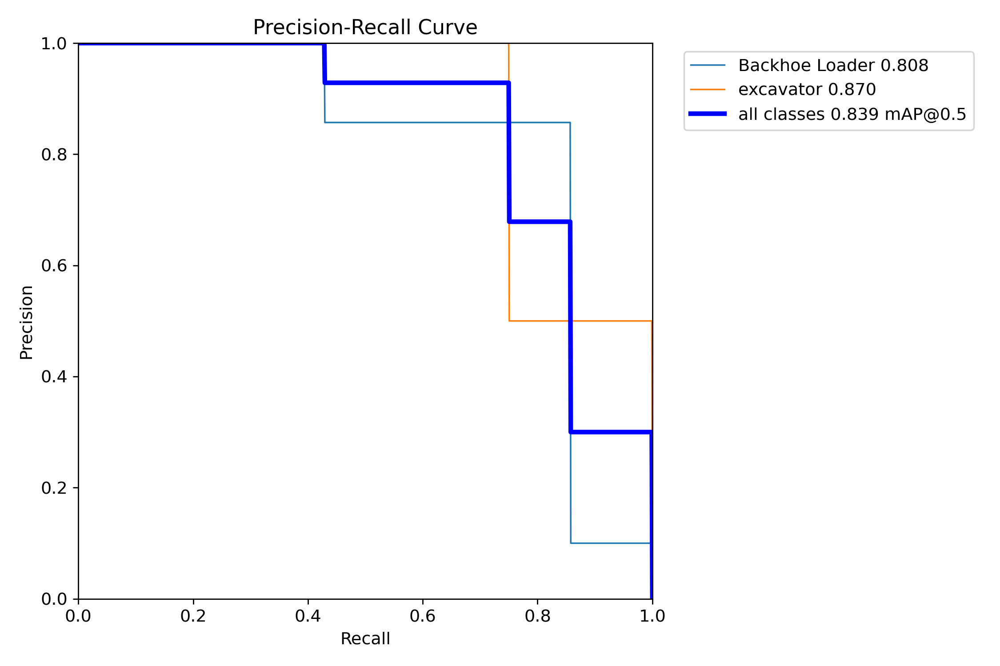

Test precision–recall curve


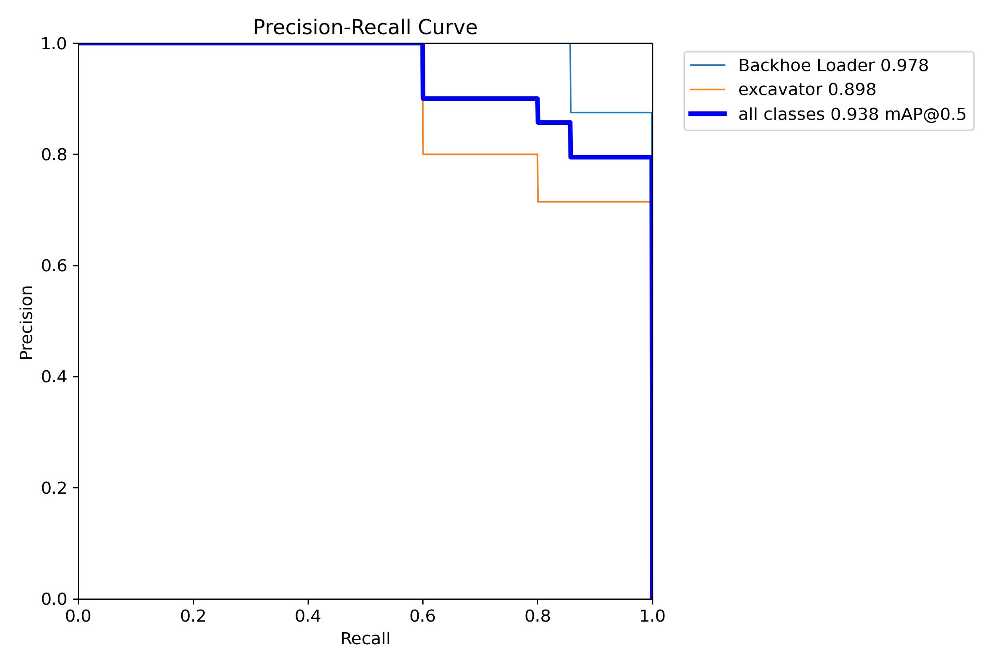

Test confusion matrix


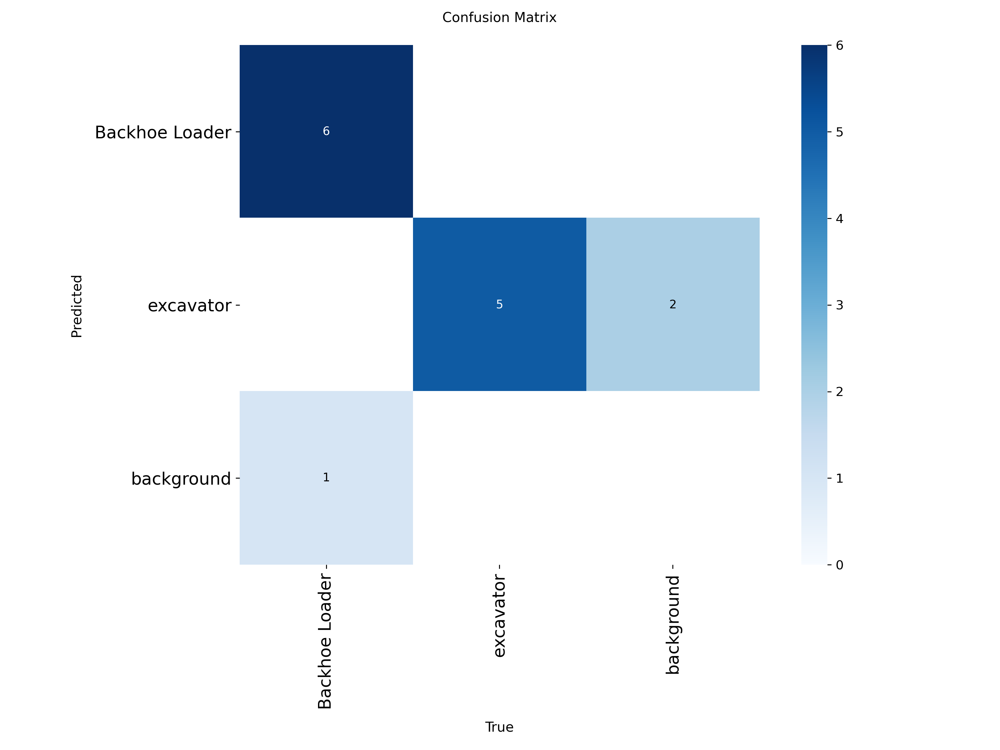

In [7]:
from IPython.display import Image, display

plots_to_review = {
    "Training precision–recall curve": train_run / "BoxPR_curve.png",
    "Test precision–recall curve": Path(test_metrics.save_dir) / "BoxPR_curve.png",
    "Test confusion matrix": Path(test_metrics.save_dir) / "confusion_matrix.png",
}

for title, path in plots_to_review.items():
    if path.exists():
        print(title)
        display(Image(filename=str(path), width=800))

The precision–recall curves have visible steps because the validation and test splits contain only 11 and 12 labelled objects respectively. Each additional correct or incorrect detection can noticeably change precision or recall. The plots are valid, but their shape and summary scores should be interpreted alongside the individual images and the small sample size.

## 7. Review individual predictions

Aggregate metrics can hide errors in particular images. Ten validation images are inspected below, including two with no labelled target. The predicted classes and box positions are compared with the labels to identify missed equipment, false alarms, and incorrect classifications.

1. 20221125_10_03_19_711_000_JDnIXPBYh0Phk7bg0iSj7cxfdP02_F_3264_2448_jpg.rf.a6eaf6a9a6b3a32008b520236eb81817.jpg | label=['Backhoe Loader'] | prediction=['Backhoe Loader']
2. 20221127_15_32_07_059_000_VT6yBAWENEVWIL828rfkS0Ku9913_F_3840_2880_jpg.rf.1cc082a8a01530752975feec268ddd97.jpg | label=['Backhoe Loader'] | prediction=['Backhoe Loader']
3. 20221129_17_27_59_218_000_5GFch1O1skRE1K4kFJFowgtsQ9u2_T_810_1080_jpg.rf.d34b95d4414557c41db44da1019f0ac5.jpg | label=['Backhoe Loader'] | prediction=['Backhoe Loader']
4. 20221130_11_27_30_621_000_it5ehLlU0ZbZwvW3GC2HcZgzVTk2_F_2448_3264_jpg.rf.d1b9201d20d2fa42d2a45afb955297b3.jpg | label=['Backhoe Loader'] | prediction=['Backhoe Loader']
5. 20221201_09_55_20_392_000_qq0XnSQqpLhSocrELdv4qYcVWK12_T_3264_4928_jpg.rf.8db16b9b40b900b70a37bc4ca083cb3d.jpg | label=['excavator'] | prediction=['excavator']
6. 20221202_07_34_20_311_000_USdKH7TY8BYXQ4xnFXuq9Avw6xV2_F_3264_2448_jpg.rf.a4182dfbe2d52c21f0b7da3a756463d1.jpg | label=['Backhoe Loader'] | pre

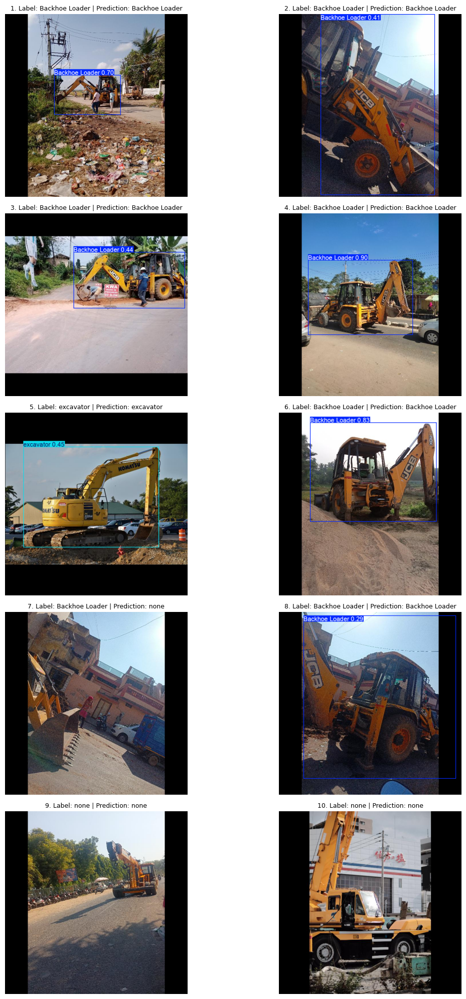

Saved grid: /content/runs/validation_predictions_grid.png


In [8]:
import matplotlib.pyplot as plt

valid_dir = Path(cfg_path).parent / "valid" / "images"
valid_images = sorted(
    p for p in valid_dir.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
)

def actual_labels(image_path):
    label_path = valid_dir.parent / "labels" / f"{image_path.stem}.txt"
    if not label_path.exists():
        return []
    return [
        best_model.names[int(line.split()[0])]
        for line in label_path.read_text().splitlines()
        if line.strip()
    ]

labelled = [p for p in valid_images if actual_labels(p)]
unlabelled = [p for p in valid_images if not actual_labels(p)]
selected = labelled[:8] + unlabelled[:2]
assert len(selected) == 10, "Expected eight labelled and two unlabelled validation images."

predictions = best_model.predict(
    source=[str(p) for p in selected],
    imgsz=640,
    conf=0.25,
    device=device,
    verbose=False,
)

fig, axes = plt.subplots(5, 2, figsize=(13, 20))

for number, (image_path, result, ax) in enumerate(
    zip(selected, predictions, axes.flat), start=1
):
    actual = actual_labels(image_path)
    predicted = [best_model.names[int(c)] for c in result.boxes.cls.tolist()]

    ax.imshow(result.plot(pil=True))
    ax.set_title(
        f"{number}. Label: {', '.join(actual) or 'none'} | "
        f"Prediction: {', '.join(predicted) or 'none'}",
        fontsize=9,
    )
    ax.axis("off")
    print(f"{number}. {image_path.name} | label={actual or ['none']} | prediction={predicted or ['none']}")

plt.tight_layout()
grid_path = Path("/content/runs/validation_predictions_grid.png")
fig.savefig(grid_path, dpi=120, bbox_inches="tight")
plt.show()
print("Saved grid:", grid_path)

## 8. Inspect predictions on the held-out test images

The summary metrics are supplemented with an image-by-image review. Predictions are displayed at a confidence threshold of 0.25 alongside the labelled class for each image. We inspect missed equipment, false alarms on images without a target, incorrect classes, and box placement. This visual threshold is used for inspection, not to tune the model on the test set.

1. 20221125_09_44_23_627_000_iAotbZL8SrOwHcTJyDar5poCETu1_F_3264_2448_jpg.rf.37874580040398070775d54550f63135.jpg | label=['Backhoe Loader'] | prediction=['Backhoe Loader 0.85']
2. 20221201_09_55_59_315_000_qq0XnSQqpLhSocrELdv4qYcVWK12_T_4024_6024_jpg.rf.8af5b8abe123249eeda2bcb818d58f43.jpg | label=['none'] | prediction=['Backhoe Loader 0.37', 'excavator 0.35']
3. 20221201_14_02_26_107_000_Ak5RiblyDfUFy1J7KDS5pf2V8Ay2_T_4160_3120_jpg.rf.c2b412fa30a3303832de00b13f24f875.jpg | label=['Backhoe Loader'] | prediction=['Backhoe Loader 0.88']
4. 20221202_18_39_00_661_000_JjJ9re25osW1m71hMlhORhHHalD2_T_4160_3120_jpg.rf.88e8537a7c438f8855f8aa53b9f62428.jpg | label=['Backhoe Loader'] | prediction=['Backhoe Loader 0.64']
5. 20221204_07_21_26_602_000_r7t0xOwkEQVPiYo1ZAP2PcFBcg42_T_3264_2448_jpg.rf.0743a529a85eb00d3147f7a9badb024f.jpg | label=['Backhoe Loader'] | prediction=['Backhoe Loader 0.78']
6. 20221204_07_21_38_734_000_r7t0xOwkEQVPiYo1ZAP2PcFBcg42_T_3264_2448_jpg.rf.ba5a6b0a85c9ac0e0104fa70c

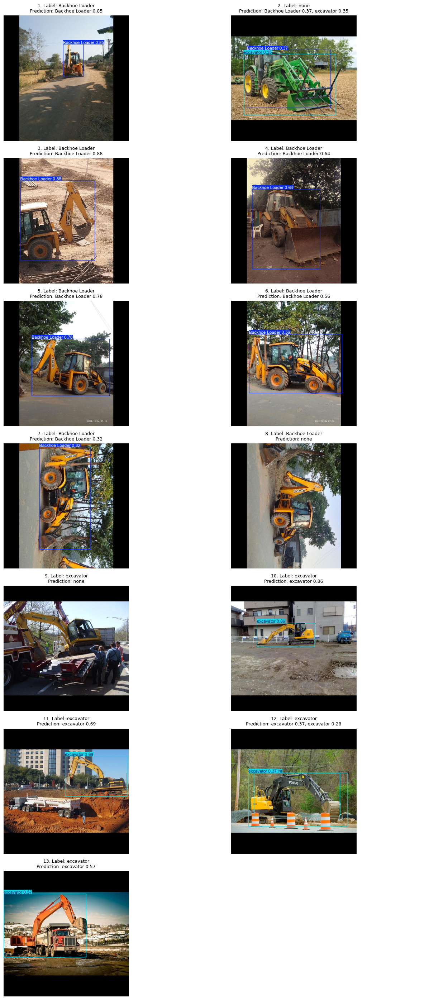

Saved grid: /content/runs/test_predictions_grid.png


In [11]:
import matplotlib.pyplot as plt
from pathlib import Path

test_root = Path(cfg_path).parent / "test"
test_images = sorted(
    p for p in (test_root / "images").iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
)

test_predictions = best_model.predict(
    source=[str(p) for p in test_images],
    imgsz=640,
    conf=0.25,
    device=device,
    verbose=False,
)

rows = (len(test_images) + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))

for ax in axes.flat:
    ax.axis("off")

for number, (image_path, result, ax) in enumerate(
    zip(test_images, test_predictions, axes.flat), start=1
):
    label_path = test_root / "labels" / f"{image_path.stem}.txt"
    lines = label_path.read_text().splitlines() if label_path.exists() else []
    actual = [
        best_model.names[int(line.split()[0])]
        for line in lines if line.strip()
    ]

    predicted = [
        f"{best_model.names[int(cls)]} {confidence:.2f}"
        for cls, confidence in zip(
            result.boxes.cls.tolist(),
            result.boxes.conf.tolist()
        )
    ]

    ax.imshow(result.plot(pil=True))
    ax.set_title(
        f"{number}. Label: {', '.join(actual) or 'none'}\n"
        f"Prediction: {', '.join(predicted) or 'none'}",
        fontsize=9,
    )
    ax.axis("off")
    print(
        f"{number}. {image_path.name} | "
        f"label={actual or ['none']} | prediction={predicted or ['none']}"
    )

plt.tight_layout()
test_grid_path = Path("/content/runs/test_predictions_grid.png")
fig.savefig(test_grid_path, dpi=120, bbox_inches="tight")
plt.show()
print("Saved grid:", test_grid_path)

### 9. Review of prediction errors

The prediction grid uses a confidence threshold of 0.25. It shows several useful limitations of this trained model:

| Example | Observation |
|---|---|
| Test image 2 | A front-loader tractor has no target label, but receives a Backhoe Loader box and an excavator box. These are two false detections on one image. |
| Test image 12 | One excavator receives two overlapping excavator boxes. Only one object is present, so the extra box is a duplicate detection. |
| Test image 8 | A labelled backhoe loader photographed sideways is missed. |
| Test image 9 | A labelled excavator on a transport vehicle is missed. |
| Validation image 7 | A partially visible backhoe loader is missed. |

These are **three false detections across two test images**, and three missed-object examples across the validation and test splits. They are not three separate false-positive photographs. The examples describe this run; predictions may change if the notebook retrains the model in a different runtime.

Three improvements for a future version are: (1) add correctly labelled front-loader tractors as negative examples to help distinguish them from backhoe loaders; (2) add more backhoe and excavator examples with varied orientations, partial views, and transport scenes; and (3) inspect the overlapping boxes and choose a confidence and duplicate-suppression setting using the validation split before evaluating on the test split.

### 10. Inference demonstration on five held-out photos

Load the trained `best.pt` checkpoint and run it on five fixed photos from the test split: two backhoe loaders, two excavators, and one negative front-loader tractor. None of these photos was used for training. The filenames are fixed so a fresh run selects the same examples; the predictions and confidence scores may change if the model is retrained. The full test metrics above still use all 13 test photos.

1. Backhoe loader — rear view: Backhoe Loader 0.85
2. Negative — front-loader tractor: Backhoe Loader 0.37, excavator 0.35
3. Backhoe loader — sideways view: none
4. Excavator — site view: excavator 0.86
5. Excavator — overlapping-box example: excavator 0.37, excavator 0.28


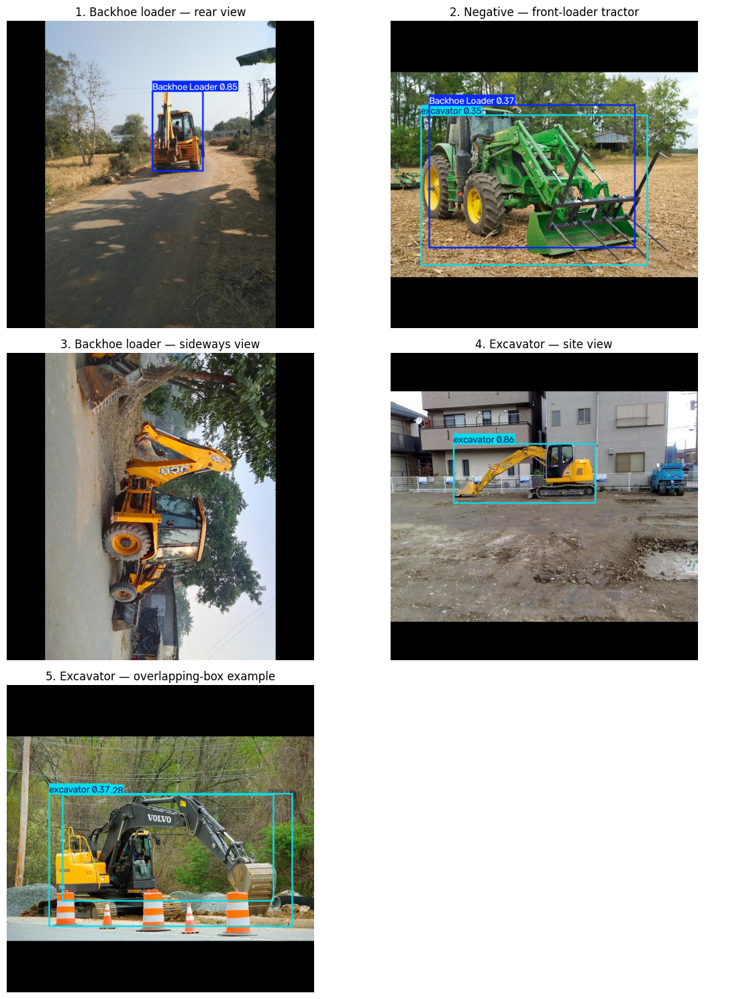

Saved demonstration grid: /content/runs/five_test_predictions.png


In [13]:
from pathlib import Path
import matplotlib.pyplot as plt
from ultralytics import YOLO

# These short IDs identify five specific files in the frozen test split.
demo_cases = [
    ("Backhoe loader — rear view", "37874580040398070775d54550f63135"),
    ("Negative — front-loader tractor", "8af5b8abe123249eeda2bcb818d58f43"),
    ("Backhoe loader — sideways view", "c30c482a1beb41436ca19f03e860e4eb"),
    ("Excavator — site view", "8887f5372e6aa57f98099b2a78dcf2d1"),
    ("Excavator — overlapping-box example", "73b401b920d17b7bdb99026084638268"),
]

test_images_dir = Path(cfg_path).parent / "test" / "images"
demo_paths = []

for title, image_id in demo_cases:
    matches = list(test_images_dir.glob(f"*.rf.{image_id}.jpg"))
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected one test image for {title}; found {len(matches)}."
        )
    demo_paths.append(matches[0])

# Load the best checkpoint from the training run, then predict.
demo_model = YOLO(str(best_path))
demo_results = demo_model.predict(
    source=[str(path) for path in demo_paths],
    imgsz=640,
    conf=0.25,
    verbose=False,
)

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for number, ((title, _), result, ax) in enumerate(
    zip(demo_cases, demo_results, axes.flat), start=1
):
    ax.imshow(result.plot()[:, :, ::-1])  # Convert BGR to RGB for display.
    ax.set_title(f"{number}. {title}")
    ax.axis("off")

    predictions = [
        f"{result.names[int(class_id)]} {confidence:.2f}"
        for class_id, confidence in zip(
            result.boxes.cls.cpu().tolist(),
            result.boxes.conf.cpu().tolist(),
        )
    ]
    print(f"{number}. {title}: {', '.join(predictions) or 'none'}")

axes.flat[-1].axis("off")
plt.tight_layout()

output_path = Path("/content/runs/five_test_predictions.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=140, bbox_inches="tight")
plt.show()

print(f"Saved demonstration grid: {output_path}")

### 11. Investigating a missed sideways backhoe loader

One labelled backhoe loader was missed in the test split, and its exported photo appears rotated sideways. Auto-Orient was included in dataset preprocessing, but the photo remained sideways. To investigate whether orientation contributed to this error, the same trained checkpoint is applied to the exported image and to a manually rotated copy. This is an exploratory comparison of one image, not a new test-set score.

As exported: none
Rotated upright: Backhoe Loader 0.81


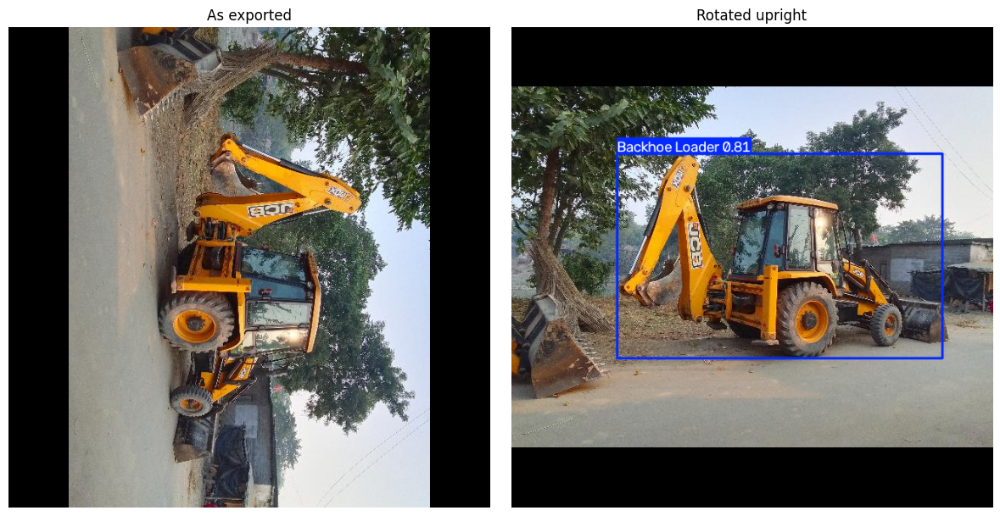

In [14]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO

image_id = "c30c482a1beb41436ca19f03e860e4eb"
matches = list((Path(cfg_path).parent / "test" / "images").glob(f"*.rf.{image_id}.jpg"))
assert len(matches) == 1, "Could not uniquely find the sideways test photo."

sideways = Image.open(matches[0]).convert("RGB")
upright = sideways.rotate(90, expand=True)  # Put the ground at the bottom.
orientation_model = YOLO(str(best_path))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, (title, photo) in zip(
    axes,
    [("As exported", sideways), ("Rotated upright", upright)]
):
    result = orientation_model.predict(
        source=photo, imgsz=640, conf=0.25, verbose=False
    )[0]

    predictions = [
        f"{result.names[int(class_id)]} {confidence:.2f}"
        for class_id, confidence in zip(
            result.boxes.cls.cpu().tolist(),
            result.boxes.conf.cpu().tolist(),
        )
    ]

    print(f"{title}: {', '.join(predictions) or 'none'}")
    ax.imshow(result.plot()[:, :, ::-1])
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

The exported sideways photo produced no detection at a confidence threshold of 0.25. After rotating the same photo upright, the same `best.pt` model detected a Backhoe Loader with confidence 0.81. This supports image orientation as a factor in this particular missed detection; it does not establish the cause of every missed detection or change the reported test metrics. For a future version, I would correct photos rotated by camera handling and add labelled examples of equipment photographed from tilted viewpoints, on sloped terrain, and partly obscured by soil or other machinery. I would test rotation augmentation when those conditions reflect the images the system is expected to receive.

## Conclusion and next steps

This project tested whether a small YOLO object detector could locate backhoe loaders and excavators in construction-site photos. That detection could be a first step toward equipment monitoring; identifying individual machines or calculating hire time would require additional data and a separate workflow.

Roboflow version 3 contains 131 exported images: 105 for training, 13 for validation, and 13 for testing. Images with neither target class were kept as negative examples. The evaluation cells above report precision, recall, mAP50, and mAP50–95 for the trained checkpoint. Because the test split contains only 13 photos and 12 labelled objects, these scores are evidence for a small proof of concept, not a reliable estimate of performance across construction sites.

The image review reveals specific limitations. The negative front-loader tractor received two false detections, and one excavator received an extra overlapping box: three false detections across two photos. A sideways backhoe loader and an excavator on a transport vehicle were missed in the test split; a partially visible backhoe loader was also missed in validation. These examples show why the numerical metrics should be read alongside the actual images.

The orientation check investigated one of those errors. The same checkpoint produced no detection on the sideways backhoe photo but detected **Backhoe Loader at 0.81** after that photo was rotated upright. This supports orientation as a factor in this specific miss without changing the original test score.

The three priorities for a future dataset and model are:

1. **Improve orientation coverage:** correct accidentally rotated photos and their annotations, and include realistic camera angles and equipment on sloped terrain. Test rotation augmentation when those views are expected in use.
2. **Add difficult negative examples:** include more front loaders and similar non-target machines so the model learns when it should draw no box.
3. **Increase independent, difficult target examples:** include excavators on transport vehicles and machines that are partly obscured by soil, other equipment, or the frame edge. Review box consistency and avoid relying on many near-duplicate views of one machine.

Overall, the model demonstrates a useful proof of concept for detecting and distinguishing backhoe loaders and excavators in individual site photos. The observed misses and extra boxes show where input handling and training data need improvement. Counting unique machines across photos or connecting detections to hire and time records would require a separate tracking and data-integration workflow.